# Solution Description
**0. Input.** 64x64 image

**1. Embedding(CNN).** Two convolutions with no padding map (B, 1, 64, 64) to (B, 64, 12, 12)

**2. Positional encoding.** Sinusoidal positional encoding with 64 dimensions is computed for all positions and added to the token features. In our case it is necessary to encode position. Sinusoidal encoding is similar to classic encoding. The choice was arbitrary.

**3. Attention.** Full self-attention. Each token is linearly projected to Query/Key/Value; the scaled dot-product `softmax(QKᵀ/√d) · V` lets every position aggregate information from every other position. This is the mechanism that can implement comparing our shape to other ones and distinguish if it's the odd one. Actually, our model is something imitating a small Transformer.

**4. Classifier.** A MLP is applied to each of the 144 tokens (no averaging over positions). It outputs one logit per position; a `softmax` over the 144 positions yields a probability distribution

**5. Rough prediction (soft-argmax).** We know the centre of each of the 144 receptive fields (field `i` along an axis is centred at `4·i + 9.5`). The rough prediction is the probability-weighted average of these centres.

**6. Offset regressor.** A second 2-layer MLP, also applied token-wise to the attention output, predicts a local correction `(Δx, Δy)` for each position. The corrections are aggregated with the same probabilities, giving a small offset.

**7. Improved prediction.** `final = Σᵢ pᵢ·Cᵢ  +  Σᵢ pᵢ·(Δx, Δy)ᵢ`. The first term picks the right cell; the second term refines the location within that cell at better resolution.

**Training strategy.** Two heads trained from scratch tend not to cooperate (the classifier hasn't found the odd shape yet, so the offsets have nothing meaningful to correct). We instead use **progressive model growth**:
1. *Stage 1* — train the single-head model (steps 0–5) with until RMSE ≈ 3.5, which signals the probability map is correct. We see that different seeds make no significant difference
2. *Stage 2* — switch on the offset head (zero-init gives identical starting predictions) and continue training the full model.
An **adaptive learning rate** (`ReduceLROnPlateau`) handles the flat regions the assignment warns about.

In [17]:
# ============================================================
# 0. Imports, device, and global reproducibility
# ============================================================
import torch, random, math, numpy as np
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

GLOBAL_SEED = 0

def set_seed(seed: int):
    """Seed every RNG so a run is exactly reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(GLOBAL_SEED)

device: cuda


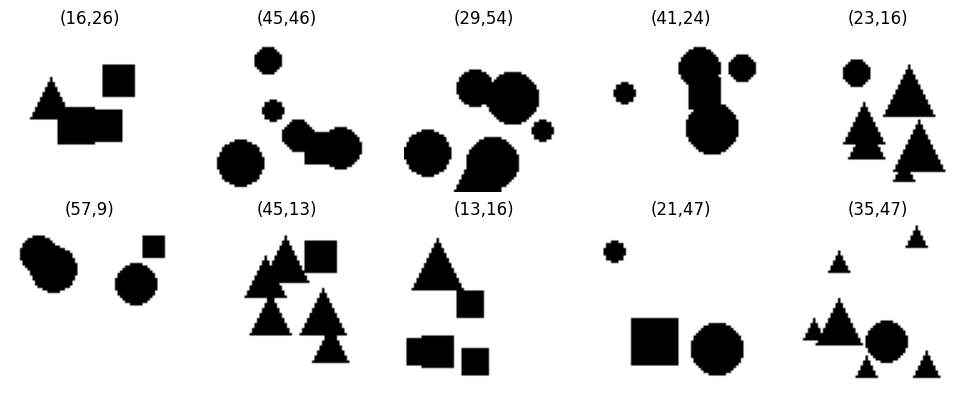

In [18]:
# ============================================================
# 1. Online dataset: 64×64, target = (cx,cy) ∈ [0,63]²  (float32)
# ============================================================
IMAGE = 64
SHAPES = ("circle", "square", "triangle")

def draw_shape(drawer, shape_type, center_x, center_y, radius):
    if shape_type == "circle":
        drawer.ellipse([center_x - radius, center_y - radius,
                        center_x + radius, center_y + radius], fill="black")
    elif shape_type == "square":
        drawer.rectangle([center_x - radius, center_y - radius,
                          center_x + radius, center_y + radius], fill="black")
    else:  # triangle
        drawer.polygon([
            (center_x, center_y - radius),
            (center_x - radius, center_y + radius),
            (center_x + radius, center_y + radius)
        ], fill="black")

class OddXYDataset(Dataset):
    """
    Generates images on-the-fly:
      * several random shapes of the same type
      * 1 additional shape of a different type
    Returns:
      * image (1×64×64 tensor, float32 normalized to [0,1])
      * label: float tensor [cx, cy] with center of the odd shape
    """
    def __init__(self, num_samples,
                 same_shape_count_range=(3, 6),
                 shape_radius_range=(4, 10)):
        self.num_samples = num_samples
        self.same_shape_count_range = same_shape_count_range
        self.radius_min, self.radius_max = shape_radius_range

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        base_shape = random.choice(SHAPES)
        odd_shape  = random.choice([s for s in SHAPES if s != base_shape])

        img = Image.new("L", (IMAGE, IMAGE), "white")
        drawer = ImageDraw.Draw(img)

        # draw identical shapes
        for _ in range(random.randint(*self.same_shape_count_range)):
            radius = random.randint(self.radius_min, self.radius_max)
            cx = random.randint(radius, IMAGE - radius - 1)
            cy = random.randint(radius, IMAGE - radius - 1)
            draw_shape(drawer, base_shape, cx, cy, radius)

        # draw the odd shape (with known center)
        radius = random.randint(self.radius_min, self.radius_max)
        cx = random.randint(radius, IMAGE - radius - 1)
        cy = random.randint(radius, IMAGE - radius - 1)
        draw_shape(drawer, odd_shape, cx, cy, radius)

        img_tensor   = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.  # (1,64,64)
        label_tensor = torch.tensor([float(cx), float(cy)], dtype=torch.float32)             # (2,)
        return img_tensor, label_tensor

def show_examples(num_examples=10):
    dataset = OddXYDataset(num_samples=num_examples)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
    num_columns = 5
    num_rows = math.ceil(num_examples / num_columns)
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 2, num_rows * 2))
    for i, (image, label) in enumerate(dataloader):
        if i >= num_examples:
            break
        image_np = image.squeeze(0).squeeze(0).numpy()   # (1,1,64,64) -> (64,64)
        cx, cy = label.squeeze(0)                        # (1,2) -> (2,)
        axes.flat[i].imshow(image_np, cmap="gray")
        axes.flat[i].set_title(f"({cx:.0f},{cy:.0f})")
        axes.flat[i].axis("off")
    for j in range(i + 1, num_rows * num_columns):
        axes.flat[j].axis("off")
    plt.tight_layout(); plt.show()

set_seed(GLOBAL_SEED)
show_examples()

In [19]:
# ============================================================
# 2. Sinusoidal positional encoding (64 dims, positions 0..143)
# ============================================================
def sinusoidal_positional_encoding(num_positions: int, dim: int) -> torch.Tensor:
    pe  = torch.zeros(num_positions, dim)                                  # (144, 64)
    pos = torch.arange(num_positions).unsqueeze(1)    # (144, 1)
    div = 10000.0 ** (-torch.arange(0, dim, 2) / dim)                          # (32,)
    pe[:, 0::2] = torch.sin(pos * div)                                     # even dims
    pe[:, 1::2] = torch.cos(pos * div)                                     # odd dims
    return pe                                                              # (144, 64)

In [20]:
# ============================================================
# 3. Self-attention block (pre-norm encoder layer, single head)
# ============================================================
class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.scale = math.sqrt(d_model)
        self.qkv   = nn.Linear(d_model, 3 * d_model)   # Q,K,V projection
        self.proj  = nn.Linear(d_model, d_model)       # output projection
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model), nn.ReLU(),
            nn.Linear(4 * d_model, d_model),
        )
        self.last_attn = None   # (B, 144, 144) cached for visualization

    def forward(self, x):                              # x: (B, 144, 64)
        h = self.norm1(x)                             # (B, 144, 64)
        q, k, v = self.qkv(h).chunk(3, dim=-1)        # each (B, 144, 64)
        scores = (q @ k.transpose(-2, -1)) / self.scale   # (B, 144, 144)
        attn   = scores.softmax(dim=-1)               # (B, 144, 144)
        self.last_attn = attn.detach()
        ctx = attn @ v                                # (B, 144, 64)
        x = x + self.proj(ctx)                        # residual (B, 144, 64)
        x = x + self.ff(self.norm2(x))               # residual (B, 144, 64)
        return x                                      # (B, 144, 64)

In [21]:
# ============================================================
# 4-7. Full model: CNN embed -> PE -> attention ->
#      classifier (soft-argmax) + offset regressor (refined pred)
# ============================================================
class OddShapeLocator(nn.Module):
    def __init__(self, d_model=64, n_layers=2, mlp_hidden=64, use_offset=False):
        super().__init__()
        self.use_offset = use_offset
        self.d_model = d_model

        # 1. CNN embedding: (B,1,64,64) -> (B,d_model,12,12), no padding
        #     stride 2*2 = 4, receptive field (6-1)*2+10 = 20  -> 144 positions
        self.conv1 = nn.Conv2d(1, 8,       kernel_size=10, stride=2)   # (B, 8, 28, 28)
        self.conv2 = nn.Conv2d(8, d_model, kernel_size=6,  stride=2)   # (B,64, 12, 12)

        # 2. positional encoding for the 144 tokens
        self.register_buffer("pos_enc",
            sinusoidal_positional_encoding(144, d_model))              # (144, 64)

        # 3. attention stack
        self.blocks = nn.ModuleList(
            [SelfAttentionBlock(d_model) for _ in range(n_layers)])

        # 4. classifier head: 64 -> hidden -> 1 logit
        self.classifier = nn.Sequential(
            nn.Linear(d_model, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 1))

        # 5. constant receptive-field centres, token t -> (x, y)
        centers = torch.zeros(144, 2)
        for t in range(144):
            row, col = divmod(t, 12)             # feature map flattened row-major (h*12+w)
            centers[t, 0] = 4 * col + 9.5        # x = column index
            centers[t, 1] = 4 * row + 9.5        # y = row index
        self.register_buffer("centers", centers) # (144, 2)

        # 6. token-wise offset regressor head: 64 -> hidden -> 2
        self.offset = nn.Sequential(
            nn.Linear(d_model, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 2))
        nn.init.zeros_(self.offset[-1].weight) # Enables progressive growth by starting
        nn.init.zeros_(self.offset[-1].bias)   # stage 2 with stage 1 final parameters



    def forward(self, img):                       # img: (B, 1, 64, 64)
        B = img.size(0)
        x = F.relu(self.conv1(img))               # (B, 8, 28, 28)
        x = F.relu(self.conv2(x))                 # (B, 64, 12, 12)
        x = x.flatten(2).transpose(1, 2)          # (B, 144, 64)  grid -> token sequence
        x = x + self.pos_enc.unsqueeze(0)         # (B, 144, 64)  inject position
        for blk in self.blocks:
            x = blk(x)                            # (B, 144, 64)
        logits = self.classifier(x).squeeze(-1)   # (B, 144)
        p = logits.softmax(dim=-1)                # (B, 144)  prob. of odd shape per position
        coarse = p @ self.centers                 # (B, 2)    soft-argmax over RF centres
        if self.use_offset:
            deltas = self.offset(x)               # (B, 144, 2)  local (dx, dy) per token
            fine   = (p.unsqueeze(-1) * deltas).sum(dim=1)  # (B, 2) prob-weighted offset
            pred   = coarse + fine                # (B, 2)    refined prediction
        else:
            pred   = coarse                       # (B, 2)
        return pred, p, logits                    # (B,2), (B,144), (B,144)

# ============================================================
# Training utilities + config
# ============================================================
BATCH_SIZE      = 256
EPOCH_SAMPLES   = 25000     # 1 epoch == 25,000 examples (assignment convention)
EPOCHS_STAGE1   = 30         # single-head stage
EPOCHS_STAGE2   = 60         # two-head (refined) stage, after 30 epochs score was still decreasing significantly, so I doubled it
RESTART_SEEDS   = [0, 1]     # multiple restarts; best stage-1 run is kept
NUM_WORKERS     = 2          # raise on Colab if data loading is the bottleneck

def make_loader(seed, n_samples=EPOCH_SAMPLES, batch_size=BATCH_SIZE):
    g = torch.Generator(); g.manual_seed(seed)
    ds = OddXYDataset(num_samples=n_samples)
    return DataLoader(ds, batch_size=batch_size, shuffle=True,
                      num_workers=NUM_WORKERS,
                      generator=g, drop_last=True)

def run_epoch(model, loader, optimizer=None):
    """One pass over `loader`. Returns exact epoch RMSE (pixels)."""
    training = optimizer is not None
    model.train(training)
    sse, n = 0.0, 0
    for img, label in loader:                       # img (B,1,64,64), label (B,2)
        img, label = img.to(device), label.to(device)
        pred, _, _ = model(img)                     # pred (B,2)
        loss = F.mse_loss(pred, label)              # scalar (mean over B and x,y)
        if training:
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        sse += ((pred - label) ** 2).sum().item()   # sum of squared errors
        n   += label.numel()                        # = 2*B
    return math.sqrt(sse / n)                        # RMSE = sqrt(MSE)

In [22]:
# ============================================================
# STAGE 1 — single-head model, multiple restarts (keep the best)
# ============================================================
def train_stage1(seed):
    set_seed(seed)
    model  = OddShapeLocator(use_offset=False).to(device)
    optim  = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.5, patience=3)
    loader = make_loader(seed=seed)
    hist = []
    print(f"\n=== STAGE 1 | restart seed={seed} ===")
    for ep in range(1, EPOCHS_STAGE1 + 1):
        rmse = run_epoch(model, loader, optim)
        sched.step(rmse)
        hist.append(rmse)
        print(f"  seed {seed} | epoch {ep:02d}/{EPOCHS_STAGE1} | "
              f"RMSE {rmse:6.3f} px | lr {optim.param_groups[0]['lr']:.1e}")
    return model, hist

runs = []
for s in RESTART_SEEDS:
    m, h = train_stage1(s)
    runs.append({"seed": s, "final_rmse": h[-1], "model": m, "hist": h})

runs.sort(key=lambda r: r["final_rmse"])
best = runs[0]
model      = best["model"]          # continue from the best stage-1 run
best_seed  = best["seed"]
hist_stage1 = best["hist"]
print(f"\n>>> best stage-1 run: seed={best_seed}  RMSE={best['final_rmse']:.3f} px")


=== STAGE 1 | restart seed=0 ===
  seed 0 | epoch 01/30 | RMSE 13.162 px | lr 2.0e-03
  seed 0 | epoch 02/30 | RMSE 12.110 px | lr 2.0e-03
  seed 0 | epoch 03/30 | RMSE 10.045 px | lr 2.0e-03
  seed 0 | epoch 04/30 | RMSE  7.971 px | lr 2.0e-03
  seed 0 | epoch 05/30 | RMSE  5.961 px | lr 2.0e-03
  seed 0 | epoch 06/30 | RMSE  5.410 px | lr 2.0e-03
  seed 0 | epoch 07/30 | RMSE  5.031 px | lr 2.0e-03
  seed 0 | epoch 08/30 | RMSE  5.093 px | lr 2.0e-03
  seed 0 | epoch 09/30 | RMSE  4.653 px | lr 2.0e-03
  seed 0 | epoch 10/30 | RMSE  4.569 px | lr 2.0e-03
  seed 0 | epoch 11/30 | RMSE  4.407 px | lr 2.0e-03
  seed 0 | epoch 12/30 | RMSE  4.535 px | lr 2.0e-03
  seed 0 | epoch 13/30 | RMSE  4.306 px | lr 2.0e-03
  seed 0 | epoch 14/30 | RMSE  4.126 px | lr 2.0e-03
  seed 0 | epoch 15/30 | RMSE  4.215 px | lr 2.0e-03
  seed 0 | epoch 16/30 | RMSE  3.998 px | lr 2.0e-03
  seed 0 | epoch 17/30 | RMSE  4.057 px | lr 2.0e-03
  seed 0 | epoch 18/30 | RMSE  3.938 px | lr 2.0e-03
  seed 0 | e

We can see that for different seeds RMSE after first stage of training is similar. From now on we will arbitrarily choose seed=1. The set has a size 25000, so a differences of shapes between sets should be insignificant.

In [23]:
# ============================================================
# STAGE 2 — enable offset head, continue from best stage-1 weights
# ============================================================
model.use_offset = True                              # turn on the (zero-init) offset head
optim  = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.5, patience=3)
loader = make_loader(seed=best_seed + 100)

hist_stage2 = []
print("=== STAGE 2 | two-head refined model ===")
for ep in range(1, EPOCHS_STAGE2 + 1):
    rmse = run_epoch(model, loader, optim)
    sched.step(rmse)
    hist_stage2.append(rmse)
    print(f"  epoch {ep:02d}/{EPOCHS_STAGE2} | RMSE {rmse:6.3f} px | "
          f"lr {optim.param_groups[0]['lr']:.1e}")

final_rmse = hist_stage2[-1]
print(f"\n>>> FINAL RMSE = {final_rmse:.3f} px "
      f"({'BONUS (<=3.0)' if final_rmse <= 3.0 else 'PASS (<=5.0)' if final_rmse <= 5.0 else 'not yet <=5.0 — try more epochs / restarts'})")

=== STAGE 2 | two-head refined model ===
  epoch 01/60 | RMSE  3.736 px | lr 1.0e-03
  epoch 02/60 | RMSE  3.596 px | lr 1.0e-03
  epoch 03/60 | RMSE  3.455 px | lr 1.0e-03
  epoch 04/60 | RMSE  3.467 px | lr 1.0e-03
  epoch 05/60 | RMSE  3.435 px | lr 1.0e-03
  epoch 06/60 | RMSE  3.372 px | lr 1.0e-03
  epoch 07/60 | RMSE  3.252 px | lr 1.0e-03
  epoch 08/60 | RMSE  3.440 px | lr 1.0e-03
  epoch 09/60 | RMSE  4.009 px | lr 1.0e-03
  epoch 10/60 | RMSE  3.387 px | lr 1.0e-03
  epoch 11/60 | RMSE  3.198 px | lr 1.0e-03
  epoch 12/60 | RMSE  3.154 px | lr 1.0e-03
  epoch 13/60 | RMSE  3.202 px | lr 1.0e-03
  epoch 14/60 | RMSE  3.135 px | lr 1.0e-03
  epoch 15/60 | RMSE  3.086 px | lr 1.0e-03
  epoch 16/60 | RMSE  2.992 px | lr 1.0e-03
  epoch 17/60 | RMSE  3.007 px | lr 1.0e-03
  epoch 18/60 | RMSE  2.991 px | lr 1.0e-03
  epoch 19/60 | RMSE  2.979 px | lr 1.0e-03
  epoch 20/60 | RMSE  3.065 px | lr 1.0e-03
  epoch 21/60 | RMSE  2.947 px | lr 1.0e-03
  epoch 22/60 | RMSE  2.954 px | lr

Best RMSE = 2.578 px achieved after 55 epochs


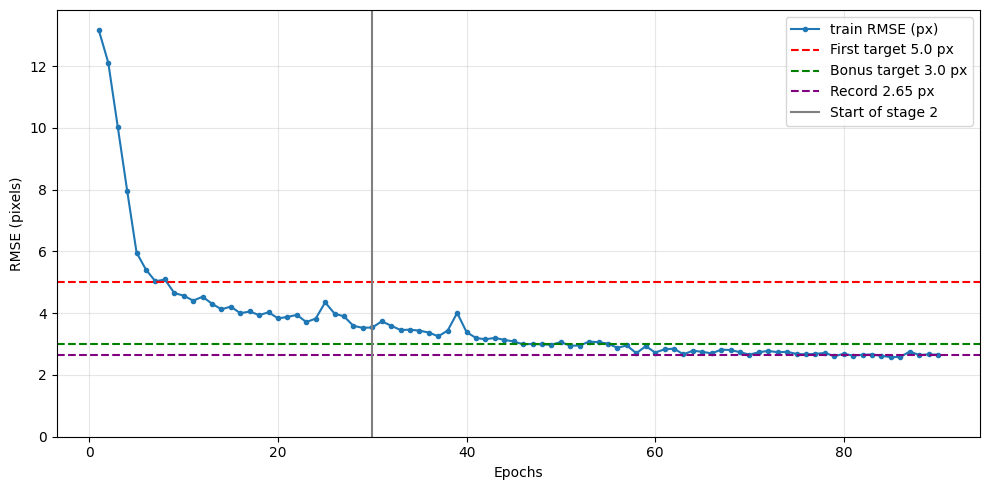

In [24]:
# ============================================================
# Learning RMSE graph
# ============================================================
full = hist_stage1 + hist_stage2
ep_axis = range(1, len(full) + 1)

plt.figure(figsize=(10, 5))
plt.plot(ep_axis, full, marker="o", ms=3, label="train RMSE (px)")
plt.axhline(5.0,  color="red",   ls="--", lw=1.5, label="First target 5.0 px")
plt.axhline(3.0,  color="green", ls="--", lw=1.5, label="Bonus target 3.0 px")
plt.axhline(2.65, color="purple",ls="--", lw=1.5, label="Record 2.65 px")
plt.axvline(30, color="gray", lw=1.5, label="Start of stage 2")
plt.xlabel("Epochs")
plt.ylabel("RMSE (pixels)")
plt.ylim(0, max(full) * 1.05)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

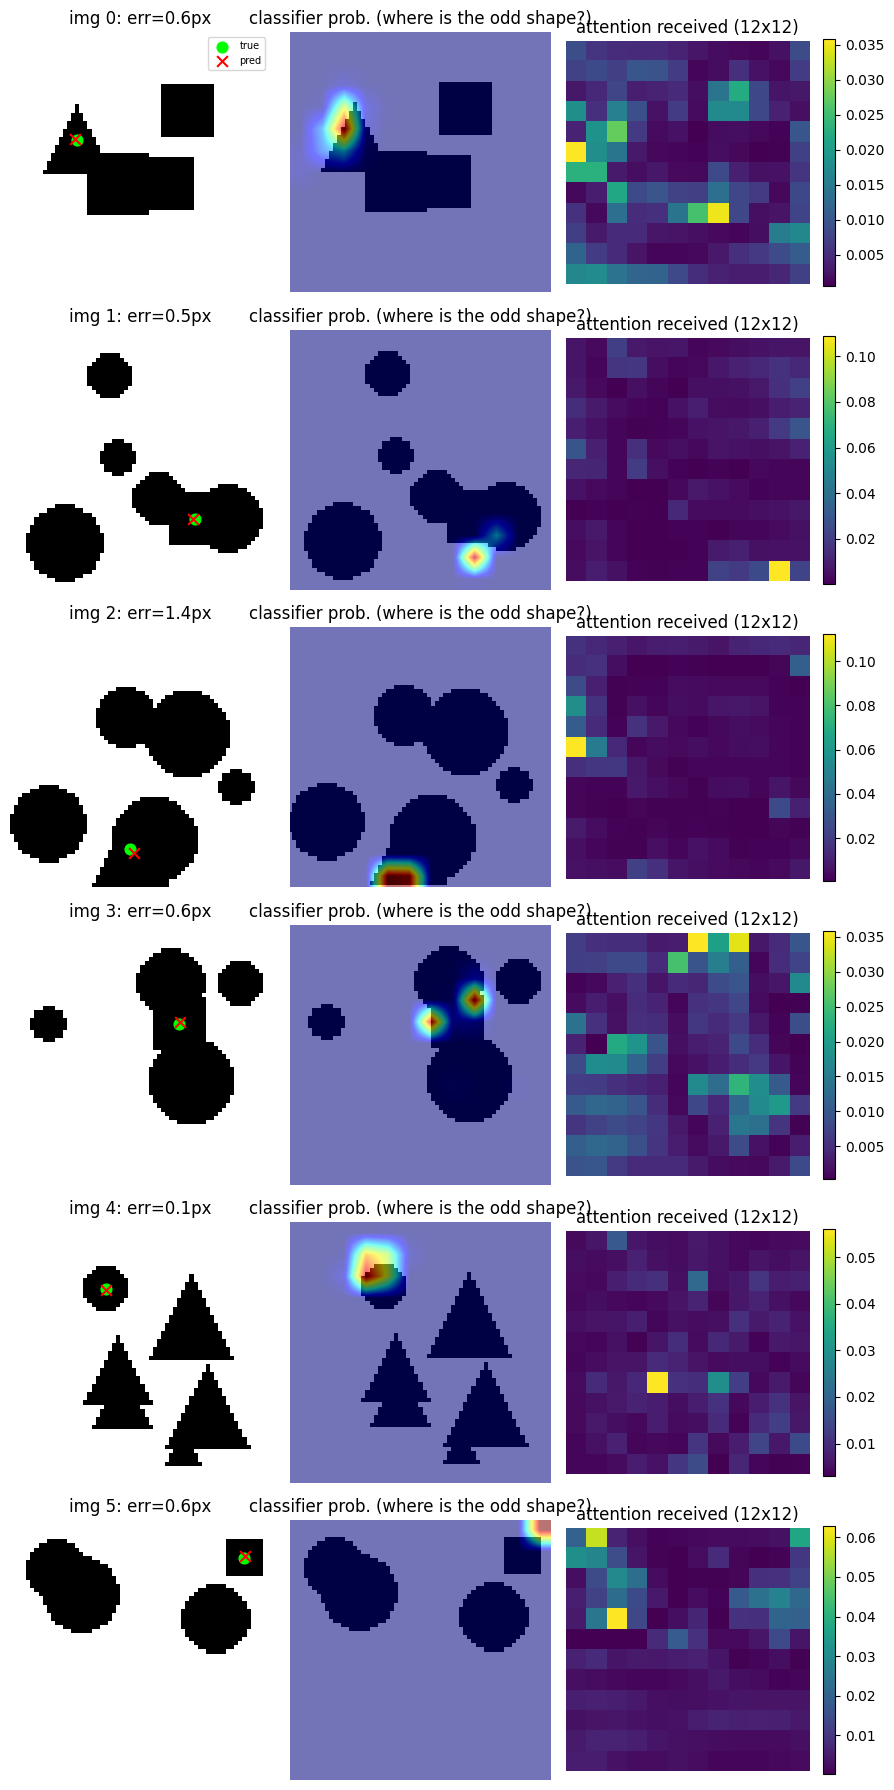

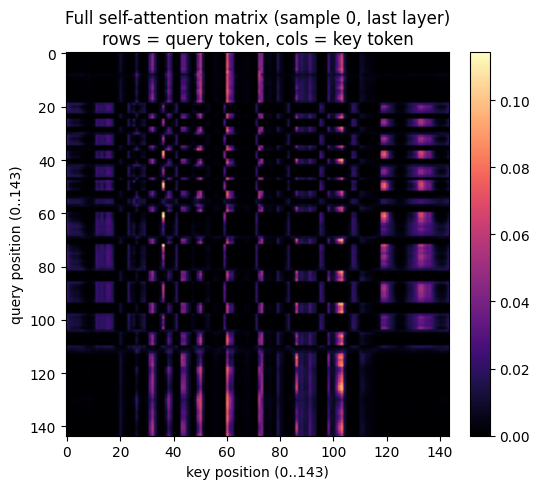

In [25]:
# ============================================================
# Attention & probability-map visualization (fixed seeded batch)
# ============================================================
set_seed(GLOBAL_SEED)
viz_loader = DataLoader(OddXYDataset(num_samples=6), batch_size=6, shuffle=False,
                        num_workers=0)
viz_imgs, viz_labels = next(iter(viz_loader))        # (6,1,64,64), (6,2)

model.eval()
with torch.no_grad():
    viz_pred, viz_p, _ = model(viz_imgs.to(device))  # (6,2), (6,144)

attn = model.blocks[-1].last_attn.cpu()   # (6, 144, 144)  attention from the last block
viz_p   = viz_p.cpu()
viz_pred = viz_pred.cpu()

n = viz_imgs.size(0)
fig, ax = plt.subplots(n, 3, figsize=(9, 3 * n))
for i in range(n):
    img = viz_imgs[i, 0].numpy()
    tx, ty = viz_labels[i]; px, py = viz_pred[i]

    # (a) image + true (green) and predicted (red x) centres
    ax[i, 0].imshow(img, cmap="gray")
    ax[i, 0].scatter([tx], [ty], c="lime", s=60, marker="o", label="true")
    ax[i, 0].scatter([px], [py], c="red",  s=60, marker="x", label="pred")
    ax[i, 0].set_title(f"img {i}: err={math.hypot(px-tx, py-ty):.1f}px")
    ax[i, 0].axis("off")
    if i == 0: ax[i, 0].legend(loc="upper right", fontsize=7)

    # (b) classifier probability map (12x12) over the image
    pmap = viz_p[i].reshape(12, 12).numpy()
    ax[i, 1].imshow(img, cmap="gray")
    ax[i, 1].imshow(pmap, cmap="jet", alpha=0.55,
                    extent=[0, 64, 64, 0], interpolation="bilinear")
    ax[i, 1].set_title("classifier prob. (where is the odd shape?)")
    ax[i, 1].axis("off")

    # (c) attention received per token (how much each position is attended to)
    attn_recv = attn[i].mean(dim=0).reshape(12, 12).numpy()   # mean over queries
    im = ax[i, 2].imshow(attn_recv, cmap="viridis")
    ax[i, 2].set_title("attention received (12x12)")
    ax[i, 2].axis("off")
    fig.colorbar(im, ax=ax[i, 2], fraction=0.046)
plt.tight_layout(); plt.show()

# Full 144x144 attention matrix for one sample
plt.figure(figsize=(5.5, 5))
plt.imshow(attn[0].numpy(), cmap="magma")
plt.title("Full self-attention matrix (sample 0, last layer)\nrows = query token, cols = key token")
plt.xlabel("key position (0..143)"); plt.ylabel("query position (0..143)")
plt.colorbar(fraction=0.046); plt.tight_layout(); plt.show()


**Where is attention?** In the "attention received" maps, attention is given near locations of shapes. It usually covers area around shapes but not exactly the position of shapes. It probably allows the model to find edges of shapes with better accuracy. Overall it gives attention to drawn shapes and ignores white background.


**Does attention correlate with the odd shape?** Kind of. As we can see in the "attention received" graph. The attention is distributed pretty evenly between all shapes. It sometimes gives more attention to "odd" shape, but it doesn't look like a strict rule. However, when we look at classifier probability it is clearly giving attention to "odd" shape. This divison of tasks is just what we wanted. First network finds shapes in the picture. Then the classifier identifies the odd one.

**Surprising patterns.** Sometimes (eg. img 0) classifier probability is spread across many shapes. It is usually in the cases, the assignment warns about e.g. when regular shapes cover the odd one, and discovering it's exact position is impossible. In those cases we can only estimate the most likely position of "odd" shape, by guessing somewhere inside regular shapes. This is actually the main source of RMSE and sets the lower bound for model accuracy.